# Image Processing for Facial Recognition
## Objective

The objective of this notebook is to preprocess face images collected from all group members by:
- Loading the images
- Displaying sample images
- Applying image augmentation techniques
- Extracting histogram features
- Saving the extracted features for later use in facial recognition.

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load Face Images

In [2]:
import os

# List to store image names and image data
images = []

# Path to raw images folder (relative to project root)
image_dir = '../data/raw/images'

# Common image file extensions
image_extensions = ('.jpg', '.jpeg', '.png')

# Loop through all uploaded files
for file in sorted(os.listdir(image_dir)):
    if file.lower().endswith(image_extensions):
        image = cv2.imread(os.path.join(image_dir, file))

        # Convert from BGR (OpenCV default) to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Store filename and image
        images.append((file, image))

print(f"Successfully loaded {len(images)} images.")


Successfully loaded 12 images.


## Display Sample Images

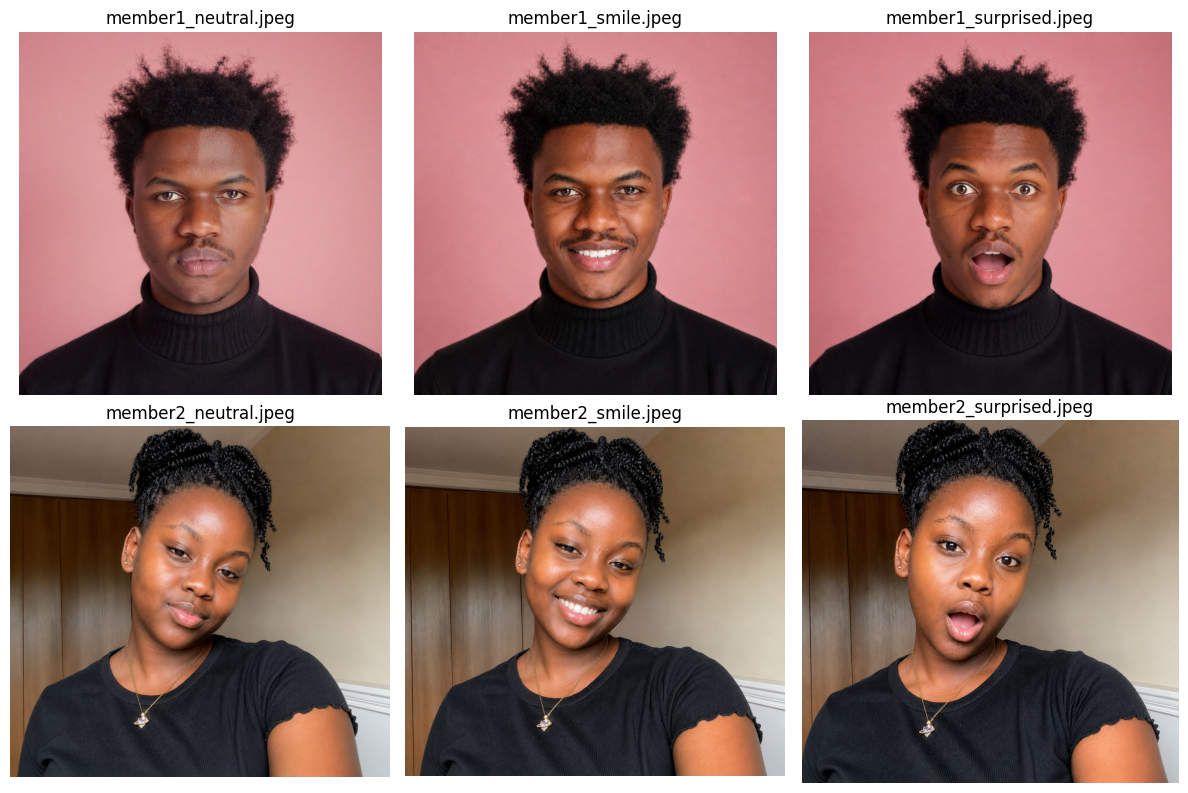

In [3]:
# Display the first 6 images
plt.figure(figsize=(12, 8))

for i, (filename, image) in enumerate(images[:6]):
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(filename)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Image Augmentation

In [4]:
# Rotate an image
def rotate_image(image, angle=15):
    height, width = image.shape[:2]
    center = (width // 2, height // 2)

    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, rotation_matrix, (width, height))

    return rotated


# Flip an image horizontally
def flip_image(image):
    return cv2.flip(image, 1)


# Convert an image to grayscale
def grayscale_image(image):
    return cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

In [5]:
# Select the first image
filename, original = images[0]

# Apply augmentations
rotated = rotate_image(original)
flipped = flip_image(original)
gray = grayscale_image(original)

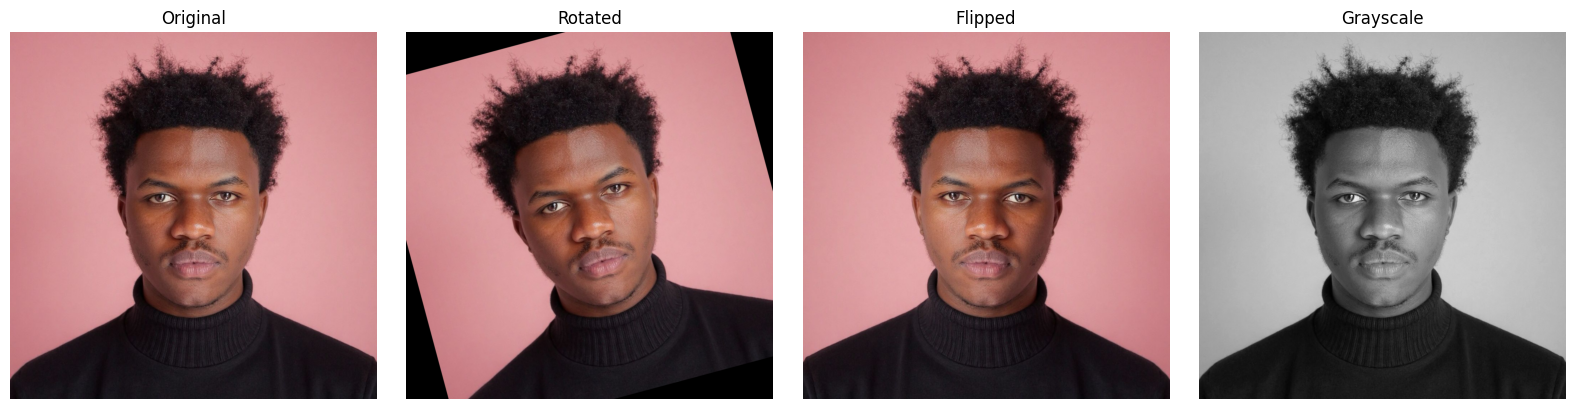

In [6]:
plt.figure(figsize=(16, 4))

# Original
plt.subplot(1, 4, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

# Rotated
plt.subplot(1, 4, 2)
plt.imshow(rotated)
plt.title("Rotated")
plt.axis("off")

# Flipped
plt.subplot(1, 4, 3)
plt.imshow(flipped)
plt.title("Flipped")
plt.axis("off")

# Grayscale
plt.subplot(1, 4, 4)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
def extract_histogram(image):
    """
    Extract a normalized grayscale histogram with 256 bins.
    """
    histogram = cv2.calcHist([image], [0], None, [256], [0, 256])

    # Normalize the histogram
    histogram = cv2.normalize(histogram, histogram)

    return histogram.flatten()

In [8]:
feature_data = []

for filename, image in images:

    # Convert image to grayscale
    gray = grayscale_image(image)

    # Extract histogram features
    histogram = extract_histogram(gray)

    # Store filename + histogram values
    row = [filename] + histogram.tolist()

    feature_data.append(row)

print(f"Extracted features from {len(feature_data)} images.")

Extracted features from 12 images.


In [9]:
columns = ["filename"] + [f"histogram_bin_{i}" for i in range(256)]

image_features_df = pd.DataFrame(feature_data, columns=columns)

image_features_df.head()

,filename,histogram_bin_0,histogram_bin_1,histogram_bin_2,histogram_bin_3,histogram_bin_4,histogram_bin_5,histogram_bin_6,histogram_bin_7,histogram_bin_8,...,histogram_bin_246,histogram_bin_247,histogram_bin_248,histogram_bin_249,histogram_bin_250,histogram_bin_251,histogram_bin_252,histogram_bin_253,histogram_bin_254,histogram_bin_255
0,member1_neutral.jpeg,0.000017,0.000238,0.000993,0.001239,0.002003,0.003090,0.005466,0.007130,0.011475,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,member1_smile.jpeg,0.004263,0.006833,0.011519,0.017544,0.024035,0.031934,0.040219,0.048123,0.054818,...,0.000075,0.000123,0.000134,0.000134,0.000096,0.000070,0.000027,0.000027,0.000059,0.000027
2,member1_surprised.jpeg,0.001124,0.008179,0.014459,0.019387,0.026720,0.037456,0.048745,0.058221,0.067313,...,0.000000,0.000000,0.000000,0.000005,0.000000,0.000000,0.000000,0.000000,0.000005,0.000000
3,member2_neutral.jpeg,0.090492,0.051684,0.035938,0.031636,0.028743,0.025713,0.023426,0.021760,0.020169,...,0.000212,0.000167,0.000091,0.000098,0.000182,0.000189,0.000144,0.000061,0.000023,0.000000
4,member2_smile.jpeg,0.099625,0.051108,0.038821,0.033816,0.029525,0.028288,0.024151,0.024320,0.020983,...,0.000507,0.000346,0.000408,0.000277,0.000392,0.000354,0.000361,0.000208,0.000031,0.000000


In [10]:
import os

output_path = '../data/processed/image_features.csv'
image_features_df.to_csv(output_path, index=False)
print(f'image_features.csv saved to {output_path}')


image_features.csv saved to ../data/processed/image_features.csv
